In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO, Profiles, MEOP
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import cmocean
import gsw
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import pickle


fname_spira = '../data/qc_profile_ds_2dbar.nc'

In [9]:
elevation_ = GEBCO(coarsen_factor=1).ds.elevation

In [10]:
full_extent = [138, 147,-68,-64]
shelf_comparison_extent = [139,146,-67,-66]
expanded_extent = [132, 156, -68, -62]

elevation = elevation_.sel(latitude = slice(expanded_extent[2], expanded_extent[3]), longitude = slice(expanded_extent[0],expanded_extent[1]))


In [11]:
p=Profiles(expanded_extent)

In [12]:
ds=p.load_profiles()

dropping dodgy profs from spira...


 59%|█████▊    | 58/99 [00:40<00:24,  1.67it/s]

skipping dodgy profile ct128-700BAT-12


 63%|██████▎   | 62/99 [00:41<00:12,  2.95it/s]

skipping dodgy profile wd15-970BAT-18


100%|██████████| 99/99 [01:03<00:00,  1.55it/s]


kept 1622 of 1663 profiles


In [13]:
ds

<xarray.Dataset> Size: 54MB
Dimensions:  (time: 6656, pres: 501)
Coordinates:
  * time     (time) datetime64[ns] 53kB 2004-10-28T21:36:00.003089408 ... 202...
    lon      (time) float64 53kB 145.2 134.3 137.5 138.1 ... 140.0 139.8 139.8
    lat      (time) float64 53kB -67.06 -63.56 -63.48 ... -66.65 -66.61 -66.61
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp     (time, pres) float64 27MB nan nan nan nan nan ... nan nan nan nan
    psal     (time, pres) float64 27MB nan nan nan nan nan ... nan nan nan nan
    mld      (time) float64 53kB 381.8 73.57 43.57 58.71 ... nan nan nan nan
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [14]:
ds['elevation'] = elevation.interp(latitude=ds.lat,longitude=ds.lon).drop_vars(['longitude','latitude'])
ds['month'] = ds.time.dt.month
ds['year'] = ds.time.dt.year


In [15]:
# compute ctemp and asal
ds['asal'] = gsw.conversions.SA_from_SP(ds.psal,ds.pres,ds.lon,ds.lat)
ds['ctemp'] = gsw.conversions.CT_from_t(ds.asal,ds.temp,ds.pres)
ds['rho'] = gsw.density.rho(ds.asal,ds.ctemp,ds.pres)
ds['sigma0'] = gsw.density.sigma0(ds.asal,ds.ctemp)

In [16]:
# set up colours
allyears = ds.groupby('time.year').mean().year
colors = plt.cm.tab20(np.linspace(0, 1, len(allyears)))
cdict = dict(zip(allyears.to_numpy(),colors))

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/structure/concat.py:674: UserWarning: No index created for dimension year because variable year is not a coordinate. To create an index for year, please first call `.set_coords('year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


In [17]:
# save areas separately
ds_full = fns.crop_to_extent(ds,full_extent)
ds_comparison = fns.crop_to_extent(ds,shelf_comparison_extent)


In [18]:
ds.to_netcdf('profiles_expanded.nc')
ds_full.to_netcdf('profiles_full.nc')
ds_comparison.to_netcdf('profiles_comparison.nc')

In [19]:
ds_full=xr.open_dataset('profiles_full.nc')
ds = xr.open_dataset('profiles_expanded.nc')

In [20]:
with open('cdict.pkl', 'wb') as file:
    pickle.dump(cdict, file)

In [21]:
ds_shelf = ds.where(ds.elevation > -1000,drop=True)

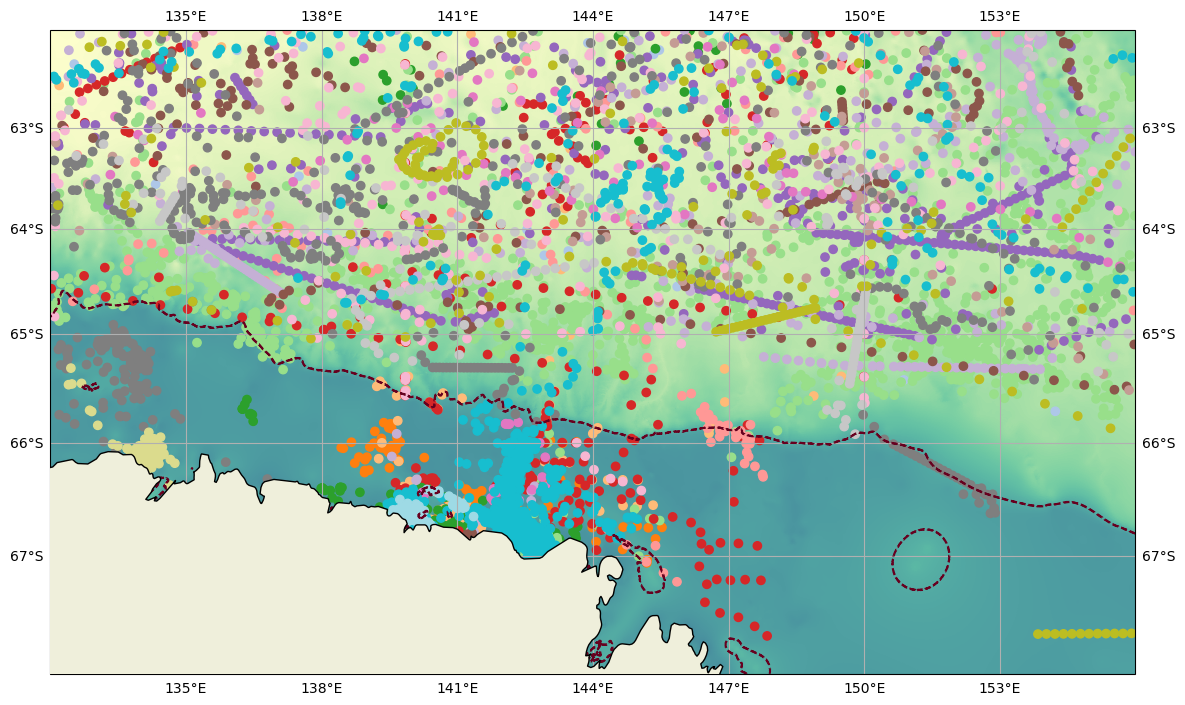

In [22]:
# location map
fig,ax=plt.subplots(figsize=(14,9),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,elevation,extent=expanded_extent,cmap=cmocean.cm.deep)
im2=ax.scatter(ds.lon,ds.lat,c=[cdict[y] for y in ds.year.data],transform=ccrs.PlateCarree())#,cmap='tab20')
elevation.plot.contour(ax=ax,levels=[-1000],transform=ccrs.PlateCarree())

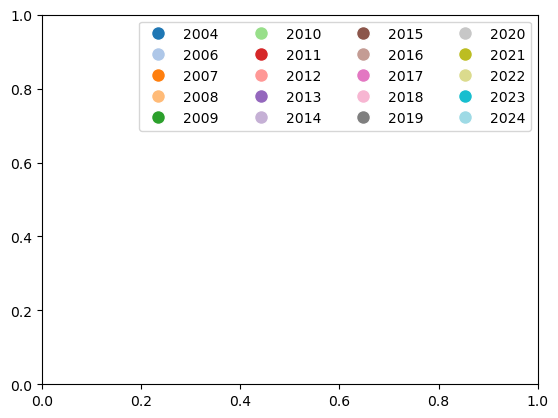

In [23]:
legend_elements = [Line2D([0],[0], color='w', markerfacecolor=cdict[y], marker='o', markersize=10, label=y) for y in cdict.keys()]
fig,ax = plt.subplots()
ax.legend(handles=legend_elements,loc='best',ncol=4)

In [24]:
rows = ['Summer','Autumn','Winter','Spring']
cols = np.arange(2005,2026,1)
ally = xr.DataArray(cols, coords={'year':cols})

In [25]:
seasons = fns.season_split(ds_shelf)

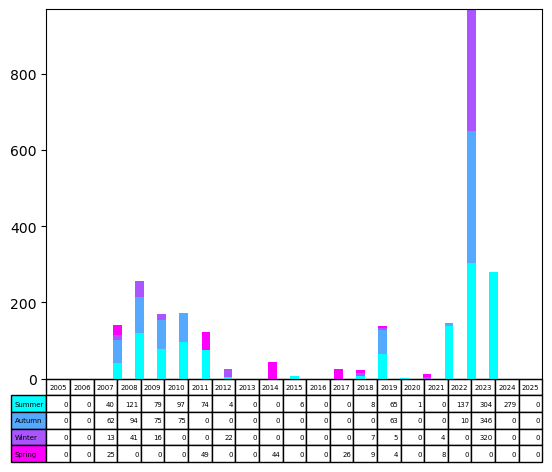

In [26]:
prep4table = lambda season: seasons[season].groupby('time.year').count().month.reindex_like(ally,fill_value=0).values
data = [prep4table('summer'),
        prep4table('autumn'),
        prep4table('winter'),
        prep4table('spring')]

# values = np.arange(0, 2500, 500)
# value_increment = 1000
# Get some pastel shades for the colors
colors = plt.cm.cool(np.linspace(0, 1, len(rows)))
n_rows = len(data)
index = np.arange(len(cols)) + 0.3
bar_width = 0.4
# Initialize the vertical-offset for the stacked bar chart.
y_offset = np.zeros(len(cols))
# Plot bars and create text labels for the table
for row in range(n_rows):
    barc = plt.bar(index, data[row], bar_width, bottom=y_offset, color=colors[row])
    y_offset = y_offset + data[row]

plt.xticks([])
# Add a table at the bottom of the axes
the_table = plt.table(cellText=data,
                      rowLabels=rows,
                      rowColours=colors,
                      colLabels=cols,
                      loc='bottom')





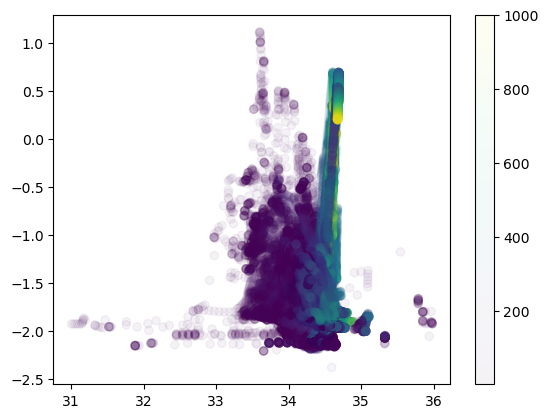

In [ ]:
fig, ax = plt.subplots(1,1)
# shapes=['o','s','*','D']
# for s,c in zip(seasons,shapes):
im=ax.scatter(ds_shelf.psal,ds_shelf.temp,alpha=0.05,c=ds_shelf.pres.broadcast_like(ds_shelf.time))
bar=plt.colorbar(im)

In [ ]:
ds_shelf.where(ds_shelf.asal > 35,drop=True)


<xarray.Dataset> Size: 325kB
Dimensions:    (time: 15, pres: 269)
Coordinates:
  * time       (time) datetime64[ns] 120B 2010-03-18T13:10:00.000001 ... 2023...
    lon        (time) float64 120B 142.6 142.3 140.2 140.2 ... 139.9 140.0 139.9
    lat        (time) float64 120B -66.74 -66.9 -66.55 ... -66.68 -66.64 -66.66
  * pres       (pres) int64 2kB 4 6 8 10 12 14 16 ... 756 758 760 762 764 766
Data variables:
    temp       (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    psal       (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    mld        (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    elevation  (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    month      (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    year       (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    asal       (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    ctemp      (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    rho        (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
    sigma0     (time, pres) float64 32kB nan nan nan nan nan ... nan nan nan nan
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [ ]:
p=Profiles([139,144,-67,-66])
dstst=p.load_profiles()

100%|██████████| 81/81 [00:54<00:00,  1.49it/s]


kept 4386 of 4439 profiles


In [4]:
# spira: 12/2017, 140-141, -66.5 - -66.8
# seasls:02-05/2023
dspira = xr.open_dataset('../data/qc_profile_ds_2dbar.nc')#.swap_dims({'n_prof':'time'})
ds=dspira.sel(time=slice(pd.Timestamp(2017,12,1),pd.Timestamp(2018,1,1))).sortby('lon').sel(lon=slice(140,141.2)).sortby('lat').sel(lat=slice(-67,-66)).load()

In [ ]:
598958, 598957, 598956

<xarray.Dataset> Size: 11GB
Dimensions:  (n_prof: 810003, pres: 501)
Coordinates:
  * n_prof   (n_prof) int64 6MB 299620 112768 220 ... 563389 563388 112036
    lon      (n_prof) float64 6MB ...
    lat      (n_prof) float64 6MB ...
    time     (n_prof) datetime64[ns] 6MB 2004-01-01T06:18:41 ... 2021-12-30T2...
  * pres     (pres) int64 4kB 0 2 4 6 8 10 12 ... 988 990 992 994 996 998 1000
Data variables:
    temp     (n_prof, pres) float64 3GB ...
    psal     (n_prof, pres) float64 3GB ...
    dsource  (n_prof) <U7 23MB ...
    mld      (n_prof) float64 6MB ...
    asal     (n_prof, pres) float32 2GB ...
    ctemp    (n_prof, pres) float32 2GB ...
    rho      (n_prof, pres) float32 2GB ...
    mlp      (n_prof) int64 6MB ...
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

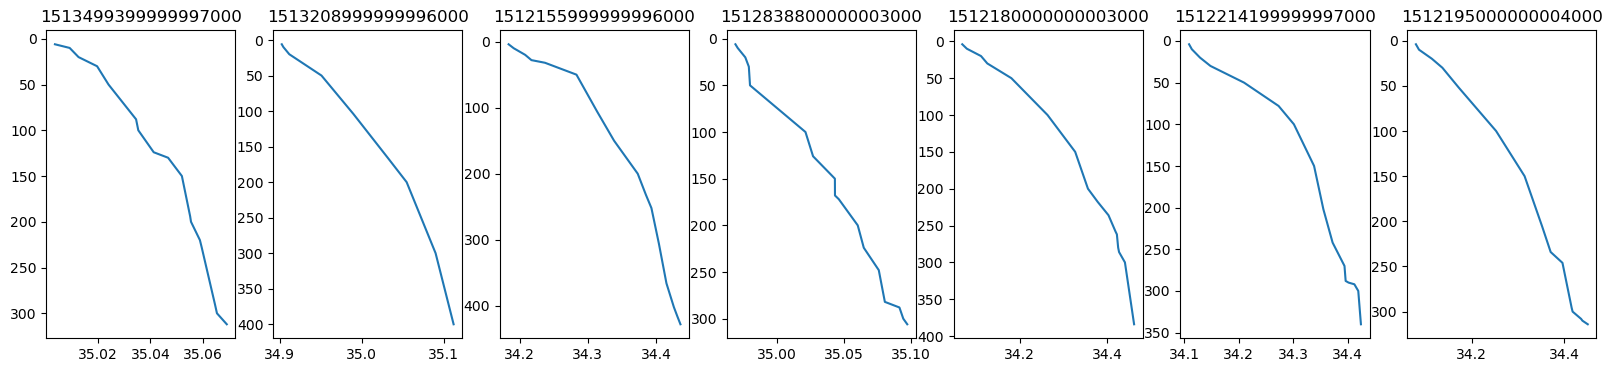

In [7]:
fig,ax = plt.subplots(1,7,figsize=(20,4))

for i,t in enumerate(ds.time):
    dt = ds.sel(time=t)
    ax[i].plot(dt.psal,dt.pres)
    ax[i].invert_yaxis()
    ax[i].set_title(str(t.item()))

In [9]:
m=MEOP([139,144,-67,-66])
m.load_profiles_for_spira()

 53%|█████▎    | 43/81 [00:26<00:21,  1.81it/s]

skipping dodgy profile ct128-700BAT-12


 58%|█████▊    | 47/81 [00:26<00:09,  3.45it/s]

skipping dodgy profile wd15-970BAT-18


100%|██████████| 81/81 [00:47<00:00,  1.70it/s]


In [11]:
m.ds.sortby('time').sel(time=slice(pd.Timestamp(2017,1,1),pd.Timestamp(2017,12,1)))

<xarray.Dataset> Size: 851kB
Dimensions:       (pres: 501, time: 104)
Coordinates:
  * pres          (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
  * time          (time) datetime64[s] 832B 2017-11-09T09:19:59 ... 2017-11-3...
    lat           (time) float64 832B -66.62 -66.63 -66.62 ... -66.67 -66.67
    lon           (time) float64 832B 140.1 140.1 140.1 ... 141.5 141.5 141.5
Data variables:
    profile_code  (time) <U20 8kB 'wd10-679-17' 'wd10-679-17' ... 'wd10-681-17'
    temp          (time, pres) float64 417kB nan nan -1.87 ... nan nan nan
    psal          (time, pres) float64 417kB nan nan 34.18 34.18 ... nan nan nan
    dsource       (time) <U5 2kB 'MEOP-' 'MEOP-' 'MEOP-' ... 'MEOP-' 'MEOP-'

In [21]:
dsm = m.ds.set_coords('profile_code')

In [22]:
dodgy_pc = ['ct128-700BAT-12', 'wd15-970BAT-18']
happy_pc = ['wd3-CTD2-07','wd11-768-18']

In [23]:
dsd0=m.ds.where(m.ds.profile_code==dodgy_pc[0])
dsd1=m.ds.where(m.ds.profile_code==dodgy_pc[1])
dsh0=m.ds.where(m.ds.profile_code==happy_pc[0])
dsh1=m.ds.where(m.ds.profile_code==happy_pc[1])


In [24]:
psal =lambda ds: ds.psal.dropna(dim='time',how='all')
temp =lambda ds: ds.temp.dropna(dim='time',how='all')

In [25]:
dsd0t = dsm.sel(time=slice(psal(dsd0).time[0],psal(dsd0).time[-1]))
dsd0t.where(~(dsd0t.profile_code == 'ct128-700BAT-12'),drop=True)

IndexError: index 0 is out of bounds for axis 0 with size 0

TypeError: No numeric data to plot.

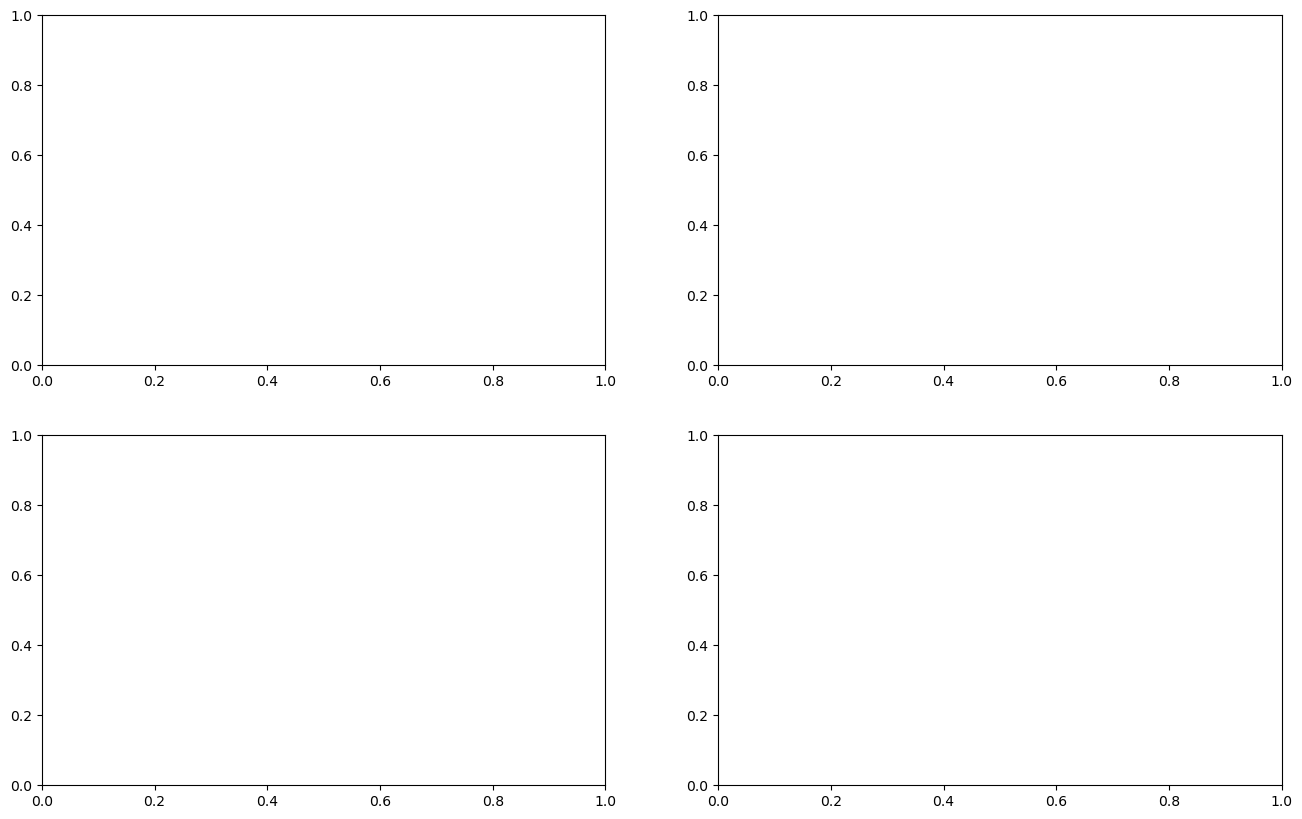

In [26]:
fig,axs = plt.subplots(2,2,figsize=(16,10))

def plot(ax,ds,ttl):
    psal(ds).plot(x='time',ax=ax)
    ax.set_ylim([0,200])
    ax.invert_yaxis()
    ax.set_title(ttl)

plot(axs[0][0],dsd0,'ct128-700BAT-12')
#plot(axs[0][1],dsd1,'wd15-970BAT-18')
plot(axs[1][0],dsh0,'normal profile')
plot(axs[1][1],dsh1,'normal profile')



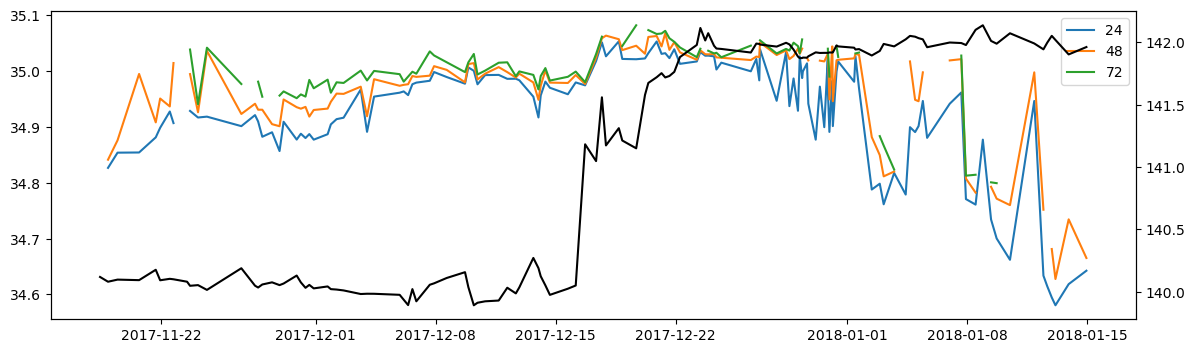

In [21]:
fig,ax = plt.subplots(1,1,figsize=(14,4))
for i,p in enumerate([24,48,72]):
    dsmpp=psal(dsd0).sel(pres=p)
    ax.plot(dsmpp.time,dsmpp,label=str(p))
    ax.legend()

ax.twinx().plot(dsmpp.time,dsmpp.lon,c='k')

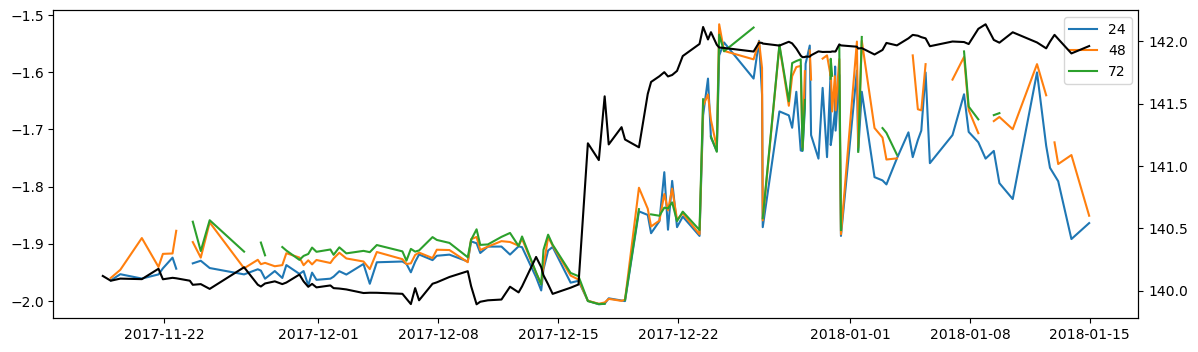

In [23]:
fig,ax = plt.subplots(1,1,figsize=(14,4))
for i,p in enumerate([24,48,72]):
    dsmpp=temp(dsd0).sel(pres=p)
    ax.plot(dsmpp.time,dsmpp,label=str(p))
    ax.legend()

ax.twinx().plot(dsmpp.time,dsmpp.lon,c='k')

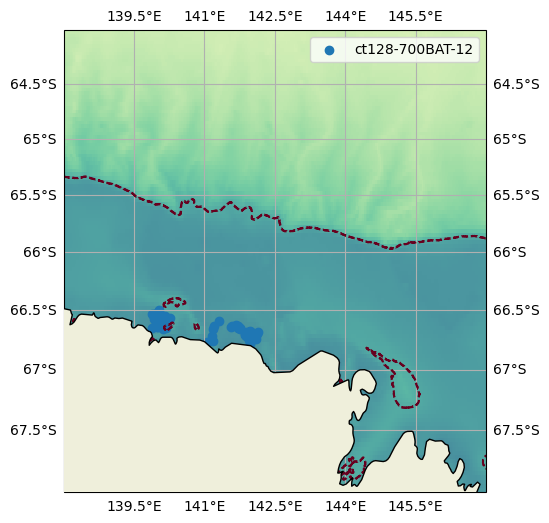

In [19]:
fig,ax=plt.subplots(figsize=(10,6),subplot_kw={'projection':ccrs.Mercator()})
im=pfns.sp(ax,elevation.coarsen({'latitude':8,'longitude':8}).mean(),extent=full_extent,cmap=cmocean.cm.deep)
ax.scatter(psal(dsd0).lon,psal(dsd0).lat,transform=ccrs.PlateCarree(),label='ct128-700BAT-12')
#ax.scatter(dsd1.lon,dsd1.lat,transform=ccrs.PlateCarree(),label='wd15-970BAT-18')

elevation.plot.contour(ax=ax,levels=[-1000],transform=ccrs.PlateCarree())
ax.legend()